In [1]:
import os, sys, glob
from tqdm import tqdm
import numpy as np
import urllib
import requests
import aiohttp
import warnings
import contextlib

import pyvo

import multiprocess as mp

from astropy.table import Column
from astropy.io import fits, ascii
from astropy.table import Table, vstack, hstack, QTable
from astropy import cosmology
from astropy import units as u
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import constants as const
from astropy.stats import sigma_clip
from astropy.stats import sigma_clipped_stats
from astropy.visualization import quantity_support
from astropy.nddata import Cutout2D

from photutils.aperture import CircularAperture
from photutils.aperture import aperture_photometry

from astroquery.ipac.irsa import Irsa

from scipy import ndimage
from scipy.interpolate import interp2d, RegularGridInterpolator, interp1d


import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as path_effects

import pandas as pd

## Plotting stuff
mpl.rcParams['font.size'] = 14
mpl.rcParams['axes.labelpad'] = 7
mpl.rcParams['xtick.major.pad'] = 7
mpl.rcParams['ytick.major.pad'] = 7
mpl.rcParams['xtick.minor.visible'] = True
mpl.rcParams['ytick.minor.visible'] = True
mpl.rcParams['xtick.minor.top'] = True
mpl.rcParams['xtick.minor.bottom'] = True
mpl.rcParams['ytick.minor.left'] = True
mpl.rcParams['ytick.minor.right'] = True
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
#mpl.rc('text', usetex=True)
mpl.rc('font', family='serif')
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['hatch.linewidth'] = 1

def_cols = plt.rcParams['axes.prop_cycle'].by_key()['color']
cosmo = cosmology.FlatLambdaCDM(H0=70,Om0=0.3)

In [ ]:
def get_spherex_exposures(ra,dec,size_arcsec):
    '''
    Collects all SPHEREx exposures for a given coordinate (ra,dec)
    '''

    ## Tip:
    # To check all IRSA collections:
    #[print(c[0]) for c in Irsa.list_collections()]

    coord = SkyCoord(ra , dec, unit = "deg" , frame = "icrs")
    size_degree = size_arcsec / 3600 # in deg
    
    # Define the service endpoint for IRSA's Table Access Protocol (TAP)
    # so that we can query SPHEREx metadata tables.
    service = pyvo.dal.TAPService("https://irsa.ipac.caltech.edu/TAP")
    
    # Define a query that will search the appropriate SPHEREx metadata tables
    # for spectral images that cover the chosen coordinates and match the
    # specified bandpass. Return the cutout data access URL and the time of observation.
    # Sort by observation time.
    query = f"""
    SELECT
        'https://irsa.ipac.caltech.edu/' || a.uri || '?center={coord.ra.degree},{coord.dec.degree}d&size={size_degree}' AS uri,
        'https://irsa.ipac.caltech.edu/' || a.uri || '?center={coord.ra.degree},{coord.dec.degree}d&size={size_degree}&ext=ZODI' AS uri_zodi,
        p.time_bounds_lower,
        'https://irsa.ipac.caltech.edu/' || a.uri AS uri_full
    FROM spherex.artifact a
    JOIN spherex.plane p ON a.planeid = p.planeid
    WHERE 1 = CONTAINS(POINT('ICRS', {coord.ra.degree}, {coord.dec.degree}), p.poly)
    ORDER BY p.time_bounds_lower
    """
    
    # Execute the query and return as an astropy Table.
    result = service.search(query)
    img_table = result.to_table()
    
    
    '''## Need to query all spherex collections separately
    img_table_allsky = Irsa.query_sia(pos=(coord, 1 * u.arcsec), collection='spherex_qr', maxrec=10000000).to_table()
    img_table_deep = Irsa.query_sia(pos=(coord, 1 * u.arcsec), collection='spherex_qr_deep', maxrec=10000000).to_table()
    #img_table_cal = Irsa.query_sia(pos=(coord, 1 * u.arcsec), collection='spherex_qr_cal', maxrec=10000000).to_table()

    ## Then combine them
    img_table = vstack([img_table_allsky,img_table_deep])'''

    
    print("Number of SPHEREx exposure: {}".format(len(img_table)))

    return(img_table)

def spherex_image_pipeline(coord, obj_name="sky", cutout_size_arcsec=60, main_path="./", CREATECUTOUTS=True, OVERWRITE=False):
    """
    SPHERExのイメージデータを取得し、指定した座標を中心とした切り出し画像を作成する関数

    Parameters
    ----------
    coord : SkyCoord
        切り出しの中心座標 (ICRS)
    obj_name : str, optional
        オブジェクトの名前 (デフォルトは "sky")
    cutout_size_arcsec : float, optional
        切り出し画像のサイズ (アーク秒単位、デフォルトは60)
    main_path : str, optional
        データを保存するディレクトリのパス (デフォルトはカレントディレクトリ)
    CREATECUTOUTS : bool, optional
        切り出し画像を作成するかどうか (デフォルトはTrue)
    OVERWRITE : bool, optional
        既存のファイルを上書きするかどうか (デフォルトはFalse)

    Returns
    -------
    tab1 : QTable
        切り出し画像に関する情報を含むテーブル
    tab2 : QTable
        切り出し画像のWCS情報を含むテーブル
    """

In [ ]:
#中心から2arcminの四角いimageを持ってくる
center = SkyCoord(ra=271.9264*u.deg, dec=65.9009*u.deg, frame="icrs")
tab1 , tab2  = spherex_image_pipeline(coord = center,
                                      obj_name = "sky(271.9264,65.9009)",
                                      cutout_size_arcsec = 60,
                                      lambda_min = 1.5,
                                      lambda_max = 1.6
                                      )

In [2]:
coord = SkyCoord(ra=271.9264*u.deg, dec=65.9009*u.deg, frame="icrs")
size_degree = 60 / 3600 # in deg
lambda_min = 1.5 #um
lambda_max = 1.6 #um
    
# Define the service endpoint for IRSA's Table Access Protocol (TAP)
# so that we can query SPHEREx metadata tables.
service = pyvo.dal.TAPService("https://irsa.ipac.caltech.edu/TAP")
    
# Define a query that will search the appropriate SPHEREx metadata tables
# for spectral images that cover the chosen coordinates and match the
# specified bandpass. Return the cutout data access URL and the time of observation.
# Sort by observation time.
query = f"""
SELECT
p.poly,
  'https://irsa.ipac.caltech.edu/' || a.uri AS uri_full
FROM spherex.artifact a
JOIN spherex.plane p ON a.planeid = p.planeid
JOIN spherex.obscore b ON p.obs_publisher_did = b.obs_publisher_did
WHERE 1 = CONTAINS(
        POINT('ICRS', {coord.ra.degree}, {coord.dec.degree}), p.poly)
        AND b.em_min <= {lambda_max*1e-6}
        AND b.em_max >= {lambda_min*1e-6}
ORDER BY p.time_bounds_lower

"""
    
# Execute the query and return as an astropy Table.
result = service.search(query)
img_table = result.to_table()
img_table

poly,uri_full
deg,
object,object
0103000020E61000000100000005000000D83981C5635455C0FD6AEE98A0454F401C2CFCB4B23057C0C68D8752E61C4F4000ACDC19108457C0D85B7EF1686A5040B045575CB46455C0FF0F8DDFA9815040D83981C5635455C0FD6AEE98A0454F40,https://irsa.ipac.caltech.edu/ibe/data/spherex/qr/level2/2025W17_4B/l2b-v13-2025-198/2/level2_2025W17_4B_0051_2D2_spx_l2b-v13-2025-198.fits
0103000020E6100000010000000500000020E681807A5555C05C47531AD25E4F40F4D5FE7BE73457C072276947CC354F40407733A9788957C0E474597ED276504028C9AFFAFC6555C0FBF3B755438E504020E681807A5555C05C47531AD25E4F40,https://irsa.ipac.caltech.edu/ibe/data/spherex/qr/level2/2025W17_4B/l2b-v13-2025-198/2/level2_2025W17_4B_0051_3D2_spx_l2b-v13-2025-198.fits
0103000020E6100000010000000500000024BE74A3A65655C016F1E78D01784F40F0CAF9193A3957C08DA4A747B24E4F4028019506158F57C02A9FF9FA37835040708D346A696755C074D7EB8DD99A504024BE74A3A65655C016F1E78D01784F40,https://irsa.ipac.caltech.edu/ibe/data/spherex/qr/level2/2025W17_4B/l2b-v13-2025-198/2/level2_2025W17_4B_0051_4D2_spx_l2b-v13-2025-198.fits
0103000020E61000000100000005000000C493A7AC786655C0C71590F9D1785040042C05815E7957C039E258A3B9565040D0FC028EB70258C0DA7D8D86362F5140BC0933163E9B55C03911D789E1565140C493A7AC786655C0C71590F9D1785040,https://irsa.ipac.caltech.edu/ibe/data/spherex/qr/level2/2025W17_4B/l2b-v13-2025-198/2/level2_2025W17_4B_0165_1D2_spx_l2b-v13-2025-198.fits
0103000020E61000000100000005000000A47C2472786655C0BF558247DA785040B40DF1305F7957C0B1BD6CE1BE5650407C06316DB80258C0A0FC23223D2F5140CC460C873C9B55C0E1FF068CE9565140A47C2472786655C0BF558247DA785040,https://irsa.ipac.caltech.edu/ibe/data/spherex/qr/level2/2025W17_4B/l2b-v13-2025-198/2/level2_2025W17_4B_0165_2D2_spx_l2b-v13-2025-198.fits
0103000020E61000000100000005000000589273ADAF3955C076F05C1DFE604F400C5CDE2CC31557C012F8F17CA1244F4044A0B808F18057C018DE19E54C6C504044ACEC00A96255C03DFFD7C0C28E5040589273ADAF3955C076F05C1DFE604F40,https://irsa.ipac.caltech.edu/ibe/data/spherex/qr/level2/2025W17_4B/l2b-v13-2025-198/2/level2_2025W17_4B_0175_1D2_spx_l2b-v13-2025-198.fits
0103000020E61000000100000005000000ECDF7FACF03B55C09B085A511F7A4F400CD8E037181B57C0C07675455C3D4F4060BABE5FD28757C0CEA51A8D997850401CBB7AAB786555C08C9A151B529B5040ECDF7FACF03B55C09B085A511F7A4F40,https://irsa.ipac.caltech.edu/ibe/data/spherex/qr/level2/2025W17_4B/l2b-v13-2025-198/2/level2_2025W17_4B_0175_2D2_spx_l2b-v13-2025-198.fits
0103000020E610000001000000050000001887A354573E55C0828869E83E934F40BCA559479A2057C069175C480A564F403052A5B0EB8E57C06DD9E5ECDB8450400C219864766855C0154A1FB1DCA750401887A354573E55C0828869E83E934F40,https://irsa.ipac.caltech.edu/ibe/data/spherex/qr/level2/2025W17_4B/l2b-v13-2025-198/2/level2_2025W17_4B_0175_3D2_spx_l2b-v13-2025-198.fits


INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]


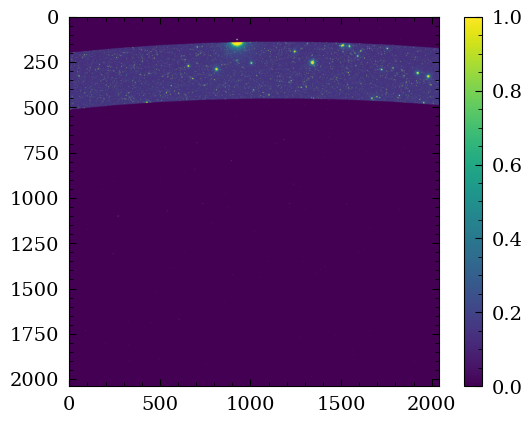

In [81]:
uri = img_table['uri_full'][0]
with fits.open(uri, memmap=True) as hdul:
    img = hdul["IMAGE"].data
    ny, nx = img.shape

    # 空間WCSじゃなく、WAVE-TAB側のWCSを取るのがポイント（key='W'）
    w_tab = WCS(hdul["IMAGE"].header, fobj=hdul, key='W')

    # 1-based の FITS ピクセル座標グリッドを作る
    yy, xx = np.mgrid[1:ny+1, 1:nx+1]

    # ピクセル→「波長,バンド幅」（WCSAXESW=2なので2面）に変換
    lam_map, band_map = w_tab.all_pix2world(xx, yy, 1)

    mask = (lam_map >= lambda_min) & (lam_map <= lambda_max)
    num = np.where(mask, img, 0.0)
    plt.imshow(img*mask, vmin=0, vmax=1)
    plt.colorbar()

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
INFO: 
             

/var/folders/k3/xbn82nk53n3d2b3ll0rk74vm0000gn/T/ipykernel_21112/2803458619.py:96: RuntimeWarning: invalid value encountered in divide
  mosaic = np.where(acc_den > 0, acc_num / acc_den, np.nan)   # MJy/sr


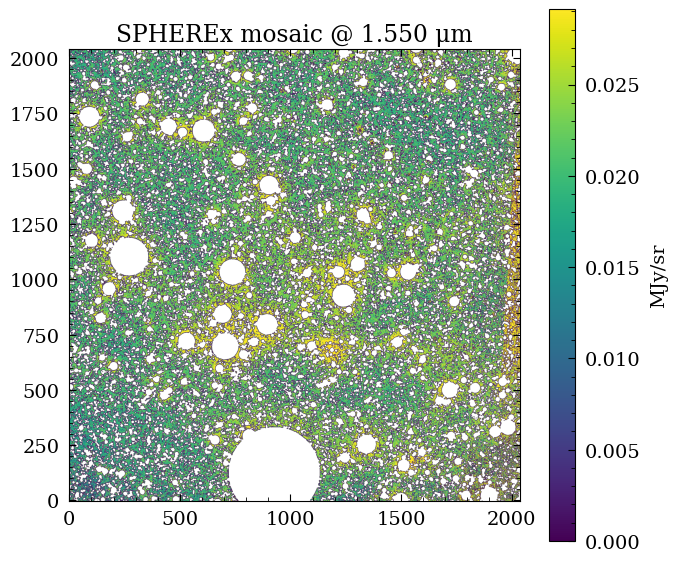

In [ ]:
import os
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from reproject import reproject_interp   # 速い。厳密さ重視なら reproject_exact
from astropy.wcs.utils import proj_plane_pixel_scales

# ==== 可変パラメータ ====
lambda0_um = 1.55          # 目標波長 [μm]
sigma_um   = None          # Noneなら各pixのbandpass(FWHM)/2.355を使う
use_invvar = True          # VARIANCE拡張の逆分散を重み付けに使う
mask_flags = True          # FLAGS拡張で非ゼロをマスク
zodi_sub   = True         # ZODI拡張を差し引く（必要なときのみTrue）

# ==== 共通WCS（基準）を決める ====
# 1) 最初のファイルの IMAGE をそのまま基準に（簡単）
with fits.open(img_table['uri_full'][0]) as hdul0:
    ref_hdr = hdul0['IMAGE'].header.copy()
    ref_wcs = WCS(ref_hdr)
    ny, nx  = hdul0['IMAGE'].data.shape

# 2) あるいは自前で解像度/範囲を定義したい場合は ref_hdr を編集（省略）

# ==== 蓄積配列（RAW/ZODI_SUB/重み/カバレッジ/フラグ枚数）====
acc_num_raw   = np.zeros((ny, nx), dtype=np.float64)
acc_num_zsub  = np.zeros((ny, nx), dtype=np.float64)
acc_den       = np.zeros((ny, nx), dtype=np.float64)
coverage_cnt  = np.zeros((ny, nx), dtype=np.float64)
flagged_cnt   = np.zeros((ny, nx), dtype=np.float64)

def per_file_lambda_slice(fname, lambda0_um, sigma_um=None):
    """1枚のFITSから λガウス重み画像 I と 重み W、そしてその空間WCSを返す"""
    with fits.open(fname) as hdul:
        img = hdul['IMAGE'].data.astype(np.float64)   # MJy/sr
        hdr = hdul['IMAGE'].header
        w_spatial = WCS(hdr)                           # 空間WCS

        # オプション：ZODI差し引き
        if zodi_sub and 'ZODI' in hdul:
            img = img - hdul['ZODI'].data.astype(np.float64)

        # マスク：FLAGS!=0 を無効化
        if mask_flags and 'FLAGS' in hdul:
            flags = hdul['FLAGS'].data
            img = np.where(flags == 0, img, np.nan)

        # 逆分散（VARIANCE拡張は画像の分散）→ 重みの乗数に
        w_invvar = None
        if use_invvar and 'VARIANCE' in hdul:
            var = hdul['VARIANCE'].data.astype(np.float64)
            w_invvar = 1.0 / np.clip(var, 1e-30, np.inf)   # 安全に

        # ----- WAVE-TAB: 2040×2040 の λ と band を取得 -----
        w_tab = WCS(hdr, fobj=hdul, key='W')   # WCS-WAVE を解釈
        ny, nx = img.shape
        yy, xx = np.mgrid[1:ny+1, 1:nx+1]      # FITSは1始まり
        lam_map, band_map = w_tab.all_pix2world(xx, yy, 1)  # [μm]

        # ガウス重み（σが無ければ bandをFWHMと見なして σ=FWHM/2.355）
        if sigma_um is None:
            sigma_map = np.maximum(band_map, 1e-6) / 2.355
        else:
            sigma_map = np.full_like(lam_map, float(sigma_um))

        dlam = lam_map - float(lambda0_um)
        w_lambda = np.exp(-0.5 * (dlam / sigma_map)**2)
        # 数値不正やband=0等を無効化
        w_lambda = np.where(np.isfinite(w_lambda), w_lambda, 0.0)

        # 総重み = λ重み × 逆分散（あれば）
        if w_invvar is not None:
            w_total = w_lambda * np.where(np.isfinite(w_invvar), w_invvar, 0.0)
        else:
            w_total = w_lambda

        # 画像NaNは重みゼロに
        good = np.isfinite(img)
        w_total = np.where(good, w_total, 0.0)

        # λスライス画像（分子）と重み（分母）
        I = img * w_total
        W = w_total
        return I, W, w_spatial

# ==== ループ：各ファイルを作って基準WCSへ再投影 → 蓄積 ====
for fn in img_table['uri_full']:
    I, W, w_this = per_file_lambda_slice(fn, lambda0_um=lambda0_um, sigma_um=sigma_um)

    # 画像（I）を再投影
    repro_I = reproject_interp((I, w_this), ref_hdr, return_footprint=False)
    # 重み（W）も同様に再投影（同じ補間法を使うのが肝）
    repro_W = reproject_interp((W, w_this), ref_hdr, return_footprint=False)

    # 蓄積
    acc_num += np.nan_to_num(repro_I, nan=0.0)
    acc_den += np.nan_to_num(repro_W, nan=0.0)

# ==== モザイク完成 ====
mosaic = np.where(acc_den > 0, acc_num / acc_den, np.nan)   # MJy/sr

# 保存（FITS）
hdu = fits.PrimaryHDU(mosaic, header=ref_hdr)
hdu.writeto(f"spherex_lambda{lambda0_um:.3f}um_mosaic_zodi.fits", overwrite=True)

# ざっとプロット
if True:
    import matplotlib.pyplot as plt
    v1, v2 = np.nanpercentile(mosaic, [5,95])
    plt.figure(figsize=(7,6))
    plt.imshow(mosaic, origin='lower', vmin=v1, vmax=v2)
    plt.colorbar(label="MJy/sr")
    plt.title(f"SPHEREx mosaic @ {lambda0_um:.3f} μm")
    plt.tight_layout()
    plt.show()



INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
INFO: 
             

/var/folders/k3/xbn82nk53n3d2b3ll0rk74vm0000gn/T/ipykernel_21112/2714711804.py:138: RuntimeWarning: invalid value encountered in divide
  mosaic_raw  = np.where(acc_den > 0, acc_num_raw  / acc_den,  np.nan)  # MJy/sr
/var/folders/k3/xbn82nk53n3d2b3ll0rk74vm0000gn/T/ipykernel_21112/2714711804.py:139: RuntimeWarning: invalid value encountered in divide
  mosaic_raw_nomask = np.where(acc_den_nomask > 0, acc_num_raw_nomask  / acc_den_nomask,  np.nan)  # MJy/sr
/var/folders/k3/xbn82nk53n3d2b3ll0rk74vm0000gn/T/ipykernel_21112/2714711804.py:140: RuntimeWarning: invalid value encountered in divide
  mosaic_zsub = np.where(acc_den > 0, acc_num_zsub / acc_den,  np.nan)  # MJy/sr
/var/folders/k3/xbn82nk53n3d2b3ll0rk74vm0000gn/T/ipykernel_21112/2714711804.py:141: RuntimeWarning: invalid value encountered in divide
  mosaic_zsub_nomask = np.where(acc_den_nomask > 0, acc_num_zsub_nomask / acc_den_nomask,  np.nan)  # MJy/sr
/var/folders/k3/xbn82nk53n3d2b3ll0rk74vm0000gn/T/ipykernel_21112/2714711804.p

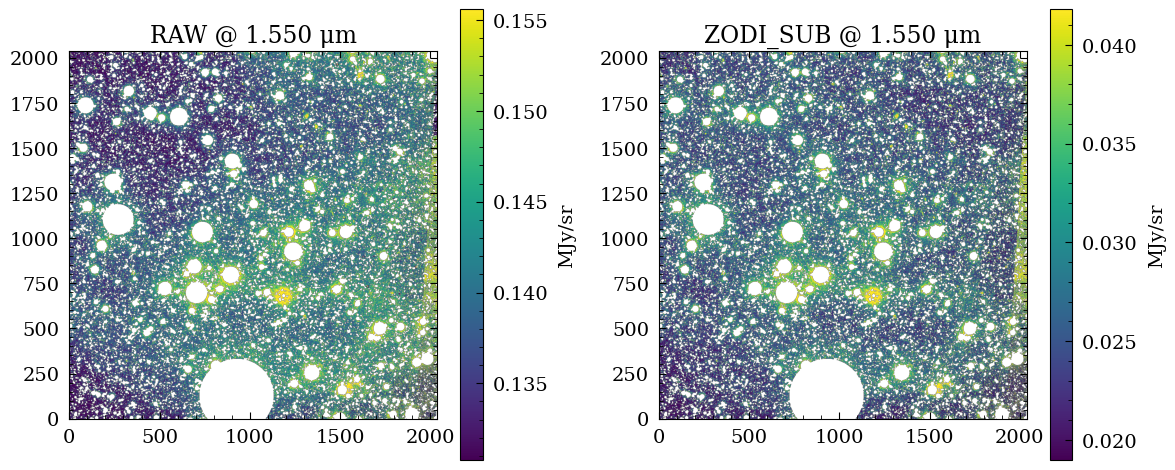

In [66]:
import os
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from reproject import reproject_interp
from astropy.wcs.utils import proj_plane_pixel_scales

# ==== 可変パラメータ ====
lambda0_um = 1.55
sigma_um   = None          # None→ 各pixのband(FWHM)/2.355
use_invvar = True
mask_flags = True
zodi_sub   = True          # ← "差し引き後"マップも出すので True のままでOK

# ==== 共通WCS（基準） ====
with fits.open(img_table['uri_full'][0]) as hdul0:
    ref_hdr = hdul0['IMAGE'].header.copy()
    ref_wcs = WCS(ref_hdr)
    ny, nx  = hdul0['IMAGE'].data.shape

# ==== 蓄積配列（RAW/ZODI_SUB/重み/カバレッジ/フラグ枚数）====
acc_num_raw   = np.zeros((ny, nx), dtype=np.float64)
acc_num_zsub  = np.zeros((ny, nx), dtype=np.float64)
acc_num_raw_nomask   = np.zeros((ny, nx), dtype=np.float64)
acc_num_zsub_nomask  = np.zeros((ny, nx), dtype=np.float64)
acc_den       = np.zeros((ny, nx), dtype=np.float64)
acc_den_nomask       = np.zeros((ny, nx), dtype=np.float64)
coverage_cnt  = np.zeros((ny, nx), dtype=np.float64)
flagged_cnt   = np.zeros((ny, nx), dtype=np.float64)

def per_file_lambda_slices(fname, lambda0_um, sigma_um=None):
    """1枚のFITSから λ重みで積分した RAW と ZODI_SUB の分子/重み/フラグ/空間WCSを返す"""
    with fits.open(fname) as hdul:
        img_raw = hdul['IMAGE'].data.astype(np.float64)   # MJy/sr
        hdr     = hdul['IMAGE'].header
        w_spat  = WCS(hdr)

        # 逆分散（重み用）
        w_invvar = None
        if use_invvar and 'VARIANCE' in hdul:
            var = hdul['VARIANCE'].data.astype(np.float64)
            w_invvar = 1.0 / np.clip(var, 1e-30, np.inf)

        # FLAGS
        flags = None
        if 'FLAGS' in hdul:
            flags = hdul['FLAGS'].data
        flag_bad = (flags is not None) & (flags != 0)

        # ZODI 差し引き版
        if zodi_sub and 'ZODI' in hdul:
            img_zsub = img_raw - hdul['ZODI'].data.astype(np.float64)
        else:
            img_zsub = img_raw.copy()

        # WAVE-TAB（λとband幅）
        w_tab = WCS(hdr, fobj=hdul, key='W')
        ny0, nx0 = img_raw.shape
        yy, xx = np.mgrid[1:ny0+1, 1:nx0+1]  # FITS 1-based
        lam_map, band_map = w_tab.all_pix2world(xx, yy, 1)  # [μm]

        # λガウス重み
        if sigma_um is None:
            sigma_map = np.maximum(band_map, 1e-6) / 2.355
        else:
            sigma_map = np.full_like(lam_map, float(sigma_um))
        dlam    = lam_map - float(lambda0_um)
        w_lambda = np.exp(-0.5 * (dlam / sigma_map)**2)
        w_lambda = np.where(np.isfinite(w_lambda), w_lambda, 0.0)

        # 総重み
        if w_invvar is not None:
            w_total = w_lambda * np.where(np.isfinite(w_invvar), w_invvar, 0.0)
        else:
            w_total = w_lambda

        # マスク適用
        w_total_nomask = w_total.copy()
        if mask_flags and (flags is not None):
            # フラグが立ったピクセルは寄与させない（重み0）
            w_total = np.where(flag_bad, 0.0, w_total)

        # NaN画素は寄与なし
        good_raw  = np.isfinite(img_raw)
        good_zsub = np.isfinite(img_zsub)
        w_for_raw  = np.where(good_raw,  w_total, 0.0)
        w_for_zsub = np.where(good_zsub, w_total, 0.0)
        w_for_raw_nomask = np.where(good_raw,  w_total_nomask, 0.0)
        w_for_zsub_nomask = np.where(good_zsub,  w_total_nomask, 0.0)

        # 分子（RAW/ZSUB）と分母（重み）
        I_raw  = img_raw  * w_for_raw
        I_zsub = img_zsub * w_for_zsub
        I_raw_nomask  = img_raw  * w_for_raw_nomask
        I_zsub_nomask = img_zsub * w_for_zsub_nomask

        # coverage用（このファイルが"有効寄与"したか：重み>0）
        cover_this = (w_total > 0).astype(np.float64)

        # flaggedカウント用（FLAGS!=0 のところを 1、それ以外 0）
        # ※マスクでw_total=0にしても、どこにフラグがあったかの情報は別途取りたいので独立に作る
        if flags is not None:
            flag_this = flag_bad.astype(np.float64)
        else:
            flag_this = np.zeros_like(cover_this)

        return I_raw, I_zsub, I_raw_nomask, I_zsub_nomask, w_total, w_total_nomask, cover_this, flag_this, w_spat

# ==== ループ ====
for fn in img_table['uri_full']:
    I_raw, I_zsub, I_raw_nomask, I_zsub_nomask, W, W_nomask, COVER, FLAG, w_this = per_file_lambda_slices(
        fn, lambda0_um=lambda0_um, sigma_um=sigma_um
    )

    # 分子と重みを同じ補間で再投影
    repro_I_raw  = reproject_interp((I_raw,  w_this), ref_hdr, return_footprint=False)
    repro_I_zsub = reproject_interp((I_zsub, w_this), ref_hdr, return_footprint=False)
    repro_I_raw_nomask  = reproject_interp((I_raw_nomask,  w_this), ref_hdr, return_footprint=False)
    repro_I_zsub_nomask = reproject_interp((I_zsub_nomask, w_this), ref_hdr, return_footprint=False)
    repro_W      = reproject_interp((W,      w_this), ref_hdr, return_footprint=False)
    repro_W_nomask      = reproject_interp((W_nomask,      w_this), ref_hdr, return_footprint=False)

    # coverage / flags は nearestでも良いが、簡便に同じ補間でOK（0/1の実数足し上げ）
    repro_cover  = reproject_interp((COVER,  w_this), ref_hdr, return_footprint=False)
    repro_flag   = reproject_interp((FLAG,   w_this), ref_hdr, return_footprint=False)

    # 蓄積
    acc_num_raw  += np.nan_to_num(repro_I_raw,  nan=0.0)
    acc_num_zsub += np.nan_to_num(repro_I_zsub, nan=0.0)
    acc_num_raw_nomask  += np.nan_to_num(repro_I_raw_nomask,  nan=0.0)
    acc_num_zsub_nomask += np.nan_to_num(repro_I_zsub_nomask, nan=0.0)
    acc_den      += np.nan_to_num(repro_W,      nan=0.0)
    acc_den_nomask      += np.nan_to_num(repro_W_nomask,      nan=0.0)
    coverage_cnt += np.nan_to_num(repro_cover,  nan=0.0)
    flagged_cnt  += np.nan_to_num(repro_flag,   nan=0.0)

# ==== モザイク ====
mosaic_raw  = np.where(acc_den > 0, acc_num_raw  / acc_den,  np.nan)  # MJy/sr
mosaic_raw_nomask = np.where(acc_den_nomask > 0, acc_num_raw_nomask  / acc_den_nomask,  np.nan)  # MJy/sr
mosaic_zsub = np.where(acc_den > 0, acc_num_zsub / acc_den,  np.nan)  # MJy/sr
mosaic_zsub_nomask = np.where(acc_den_nomask > 0, acc_num_zsub_nomask / acc_den_nomask,  np.nan)  # MJy/sr
flagged_frac = np.where(coverage_cnt > 0, flagged_cnt / coverage_cnt, np.nan)

# ==== 出力FITS（拡張つき）====
hdul_out = fits.HDUList()

# Primaryはヘッダそのまま＋最もよく使うマップ（例：ZODI_SUB）
prim = fits.PrimaryHDU(mosaic_zsub, header=ref_hdr)
prim.header['BUNIT']   = 'MJy/sr'
prim.header['DESC']    = 'Weighted mosaic at lambda0 with ZODI subtracted'
prim.header['LAMBDA0'] = (lambda0_um, 'um')
prim.header['SIGMA']   = (sigma_um if sigma_um is not None else -1.0, 'um; -1 means FWHM/2.355 per-pixel')
prim.header['INVVAR']  = (bool(use_invvar), 'Used inverse variance weighting')
prim.header['MSKFLAG'] = (bool(mask_flags), 'Masked FLAGS!=0 before averaging')
hdul_out.append(prim)

# 他の拡張（名前付き）
exts = [
    ('MOSAIC_RAW',  mosaic_raw,   'MJy/sr', 'Weighted mosaic at lambda0 (RAW, no ZODI subtraction)'),
    ('MOSAIC_RAW_NOMASK',  mosaic_raw_nomask,   'MJy/sr', 'Weighted mosaic at lambda0 (RAW, no ZODI subtraction, no FLAGS masking)'),
    ('MOSAIC_ZSUB', mosaic_zsub,  'MJy/sr', 'Weighted mosaic at lambda0 with ZODI subtracted'),
    ('MOSAIC_ZSUB_NOMASK', mosaic_zsub_nomask,  'MJy/sr', 'Weighted mosaic at lambda0 with ZODI subtracted, no FLAGS masking'),
    ('WEIGHT',      acc_den,      'arb',    'Sum of weights used in averaging'),
    ('COVERAGE',    coverage_cnt, 'count',  'Effective contributing frames (approx)'),
    ('FLAGGED_CT',  flagged_cnt,  'count',  'Number of contributing frames with FLAGS!=0'),
    ('FLAGGED_FR',  flagged_frac, 'frac',   'FLAGGED_CT / COVERAGE'),
]

for name, data, bunit, desc in exts:
    hdu = fits.ImageHDU(data.astype(np.float32), header=ref_hdr, name=name)
    hdu.header['BUNIT'] = bunit
    hdu.header['DESC']  = desc
    hdul_out.append(hdu)

outname = f"spherex_lambda{lambda0_um:.3f}um_mosaic_all.fits"
hdul_out.writeto(outname, overwrite=True)

# クイック表示（ZODI差し引き前後）
if True:
    import matplotlib.pyplot as plt
    v1r, v2r   = np.nanpercentile(mosaic_raw,  [5, 95])
    v1z, v2z   = np.nanpercentile(mosaic_zsub, [5, 95])

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.imshow(mosaic_raw, origin='lower', vmin=v1r, vmax=v2r)
    plt.colorbar(label='MJy/sr'); plt.title('RAW @ %.3f μm' % lambda0_um)

    plt.subplot(1,2,2)
    plt.imshow(mosaic_zsub, origin='lower', vmin=v1z, vmax=v2z)
    plt.colorbar(label='MJy/sr'); plt.title('ZODI_SUB @ %.3f μm' % lambda0_um)
    plt.tight_layout(); plt.show()


In [67]:
file = "spherex_lambda1.550um_mosaic_all.fits"
hdu = fits.open(file)
hdu.info()

Filename: spherex_lambda1.550um_mosaic_all.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  IMAGE         1 PrimaryHDU     221   (2040, 2040)   float64   
  1  MOSAIC_RAW    1 ImageHDU       218   (2040, 2040)   float32   
  2  MOSAIC_RAW_NOMASK    1 ImageHDU       218   (2040, 2040)   float32   
  3  MOSAIC_ZSUB    1 ImageHDU       218   (2040, 2040)   float32   
  4  MOSAIC_ZSUB_NOMASK    1 ImageHDU       218   (2040, 2040)   float32   
  5  WEIGHT        1 ImageHDU       218   (2040, 2040)   float32   
  6  COVERAGE      1 ImageHDU       218   (2040, 2040)   float32   
  7  FLAGGED_CT    1 ImageHDU       218   (2040, 2040)   float32   
  8  FLAGGED_FR    1 ImageHDU       218   (2040, 2040)   float32   


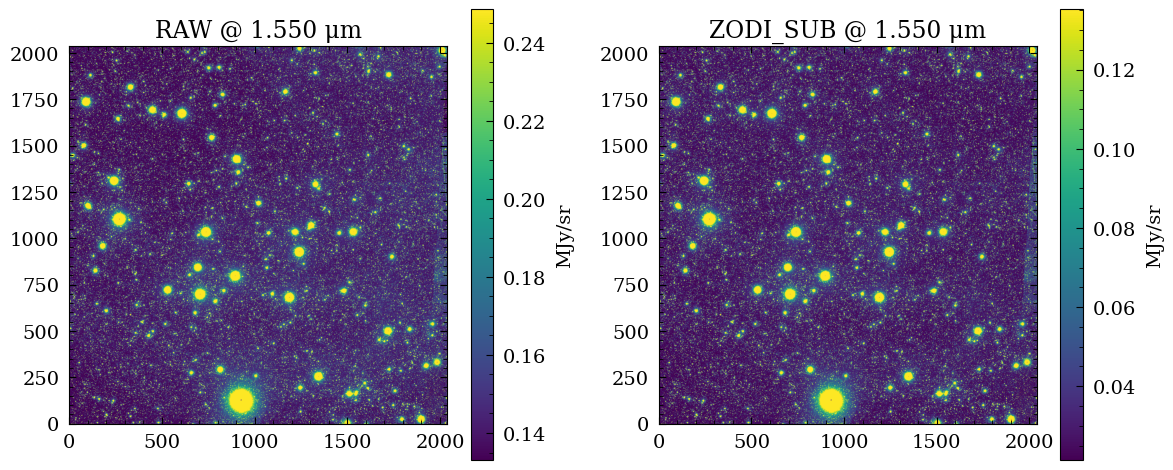

In [68]:
zodi = hdu['MOSAIC_ZSUB_NOMASK'].data
raw  = hdu['MOSAIC_RAW_NOMASK'].data
v1r, v2r   = np.nanpercentile(raw,  [5, 95])
v1z, v2z   = np.nanpercentile(zodi, [5, 95])

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(raw, origin='lower', vmin=v1r, vmax=v2r)
plt.colorbar(label='MJy/sr'); plt.title('RAW @ %.3f μm' % lambda0_um)

plt.subplot(1,2,2)
plt.imshow(zodi, origin='lower', vmin=v1z, vmax=v2z)
plt.colorbar(label='MJy/sr'); plt.title('ZODI_SUB @ %.3f μm' % lambda0_um)
plt.tight_layout()

plt.show()